# Inter-Category Comparison
```text
1. DoS/DDoS vs Brute Force  Many common features
2. DoS/DDoS vs Botnet       Time-related features are low in both
3. Brute Force vs Botnet    Flow Duration is low in both
```

In [19]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

df = pd.read_csv(r'../data/05_train_with_category.csv')

# numeric columns (exclude Label, Category)
exclude_cols = ['Label', 'Category']
numeric_cols = [col for col in df.select_dtypes(include=[np.number]).columns if col not in exclude_cols]

In [20]:
# Inter-category comparison function

def compare_two_categories(df, cat1, cat2, numeric_cols, top_n=15):
    """
    Direct comparison between two categories
    """
    data1 = df[df['Category'] == cat1]
    data2 = df[df['Category'] == cat2]
    
    print(f"\n{'='*70}")
    print(f"[{cat1}] vs [{cat2}]")
    print(f"{'='*70}")
    print(f"{cat1}: {len(data1)} samples")
    print(f"{cat2}: {len(data2)} samples")
    
    results = []
    
    for feat in numeric_cols:
        vals1 = data1[feat].replace([np.inf, -np.inf], np.nan).dropna()
        vals2 = data2[feat].replace([np.inf, -np.inf], np.nan).dropna()
        
        if len(vals1) < 10 or len(vals2) < 10:
            continue
        
        mean1 = vals1.mean()
        mean2 = vals2.mean()
        std1 = vals1.std()
        std2 = vals2.std()
        
        # Ratio (cat1 / cat2)
        if mean2 != 0:
            ratio = mean1 / mean2
        else:
            ratio = np.inf if mean1 > 0 else 0
        
        # Welch's t-test
        t_stat, p_value = stats.ttest_ind(vals1, vals2, equal_var=False)
        
        # Cohen's d
        pooled_std = np.sqrt((std1**2 + std2**2) / 2)
        if pooled_std > 0:
            cohens_d = abs(mean1 - mean2) / pooled_std
        else:
            cohens_d = 0
        
        # Direction (which category is higher)
        if mean1 > mean2:
            direction = f"{cat1} > {cat2}"
        else:
            direction = f"{cat2} > {cat1}"
        
        results.append({
            'Feature': feat,
            f'{cat1}_Mean': mean1,
            f'{cat2}_Mean': mean2,
            'Ratio': ratio,
            'Cohen_d': cohens_d,
            'p_value': p_value,
            'Direction': direction
        })
    
    # Convert to DataFrame
    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values('Cohen_d', ascending=False)
    
    return results_df

In [21]:
print("Key 3-Pair Comparison")

# Comparison 1: DoS/DDoS vs Brute Force
comp1 = compare_two_categories(df, 'DoS/DDoS', 'Brute Force', numeric_cols)

# Comparison 2: DoS/DDoS vs Botnet
comp2 = compare_two_categories(df, 'DoS/DDoS', 'Botnet', numeric_cols)

# Comparison 3: Brute Force vs Botnet
comp3 = compare_two_categories(df, 'Brute Force', 'Botnet', numeric_cols)

Key 3-Pair Comparison

[DoS/DDoS] vs [Brute Force]
DoS/DDoS: 8145 samples
Brute Force: 2324 samples

[DoS/DDoS] vs [Botnet]
DoS/DDoS: 8145 samples
Botnet: 1327 samples

[Brute Force] vs [Botnet]
Brute Force: 2324 samples
Botnet: 1327 samples


In [22]:
# Print results: Top 10 distinguishing features

def print_top_features(comp_df, cat1, cat2, top_n=10):
    print(f"\n[{cat1} vs {cat2}] Top {top_n} Features with High Discriminative Power")
    print("-" * 80)
    
    top = comp_df.head(top_n)
    for i, row in top.iterrows():
        print(f"{row['Feature']:30s} | Cohen's d: {row['Cohen_d']:6.2f} | "
              f"Ratio: {row['Ratio']:10.4f} | {row['Direction']}")

print_top_features(comp1, 'DoS/DDoS', 'Brute Force')
print_top_features(comp2, 'DoS/DDoS', 'Botnet')
print_top_features(comp3, 'Brute Force', 'Botnet')


[DoS/DDoS vs Brute Force] Top 10 Features with High Discriminative Power
--------------------------------------------------------------------------------
Dst Port                       | Cohen's d:   2.24 | Ratio:     3.0089 | DoS/DDoS > Brute Force
Bwd Pkts/s                     | Cohen's d:   1.89 | Ratio:     0.1752 | Brute Force > DoS/DDoS
Flow Pkts/s                    | Cohen's d:   1.89 | Ratio:     0.1753 | Brute Force > DoS/DDoS
Fwd Pkts/s                     | Cohen's d:   1.89 | Ratio:     0.1754 | Brute Force > DoS/DDoS
Pkt Len Mean                   | Cohen's d:   1.81 | Ratio:        inf | DoS/DDoS > Brute Force
Pkt Size Avg                   | Cohen's d:   1.79 | Ratio:        inf | DoS/DDoS > Brute Force
Pkt Len Max                    | Cohen's d:   1.66 | Ratio:        inf | DoS/DDoS > Brute Force
Init Bwd Win Byts              | Cohen's d:   1.65 | Ratio:        inf | DoS/DDoS > Brute Force
Pkt Len Std                    | Cohen's d:   1.64 | Ratio:        inf | DoS/

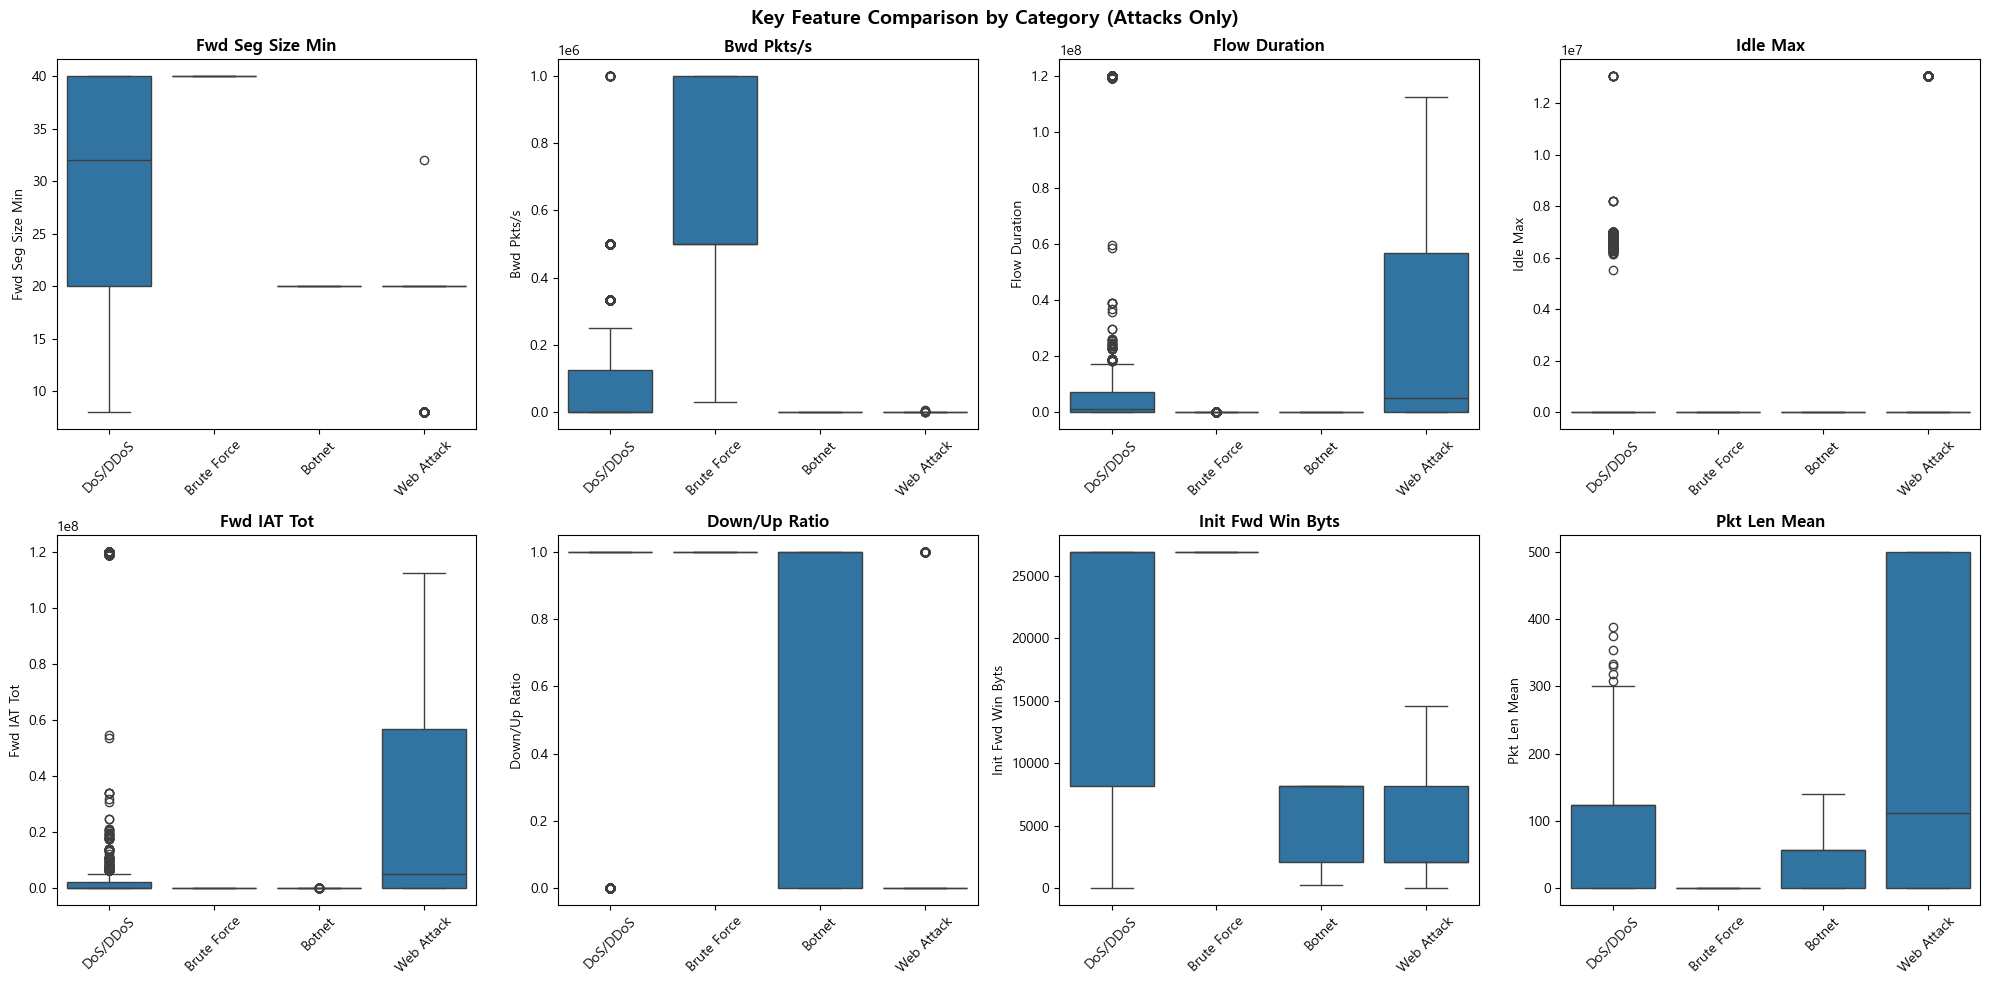

In [23]:
# Visualization: Key Feature Comparison Box Plot

# Key features used in each category's rules
key_features = [
    'Fwd Seg Size Min',      # Unique to Brute Force
    'Bwd Pkts/s',            # High in Brute Force
    'Flow Duration',         # Low in Brute Force and Botnet
    'Idle Max',              # Low in DoS/DDoS
    'Fwd IAT Tot',           # Extremely low in Botnet
    'Down/Up Ratio',         # High in DoS and Brute Force
    'Init Fwd Win Byts',     # High in DoS and Brute Force
    'Pkt Len Mean'           # Low in Botnet
]

# Extract attack categories only (exclude Benign)
attacks_only = df[df['Category'] != 'Benign'].copy()

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    if feat in attacks_only.columns:
        ax = axes[i]
        
        # Log scale or percentile clip to remove outliers
        plot_data = attacks_only[[feat, 'Category']].copy()
        
        # Clip extreme values (1%, 99%)
        lower = plot_data[feat].quantile(0.01)
        upper = plot_data[feat].quantile(0.99)
        plot_data[feat] = plot_data[feat].clip(lower, upper)
        
        sns.boxplot(data=plot_data, x='Category', y=feat, ax=ax,
                   order=['DoS/DDoS', 'Brute Force', 'Botnet', 'Web Attack'])
        ax.set_title(f'{feat}', fontsize=12, fontweight='bold')
        ax.set_xlabel('')
        ax.tick_params(axis='x', rotation=45)

plt.suptitle('Key Feature Comparison by Category (Attacks Only)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()